In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from probjax.nn.layers.attention import flex_attention, dot_product_attention, BlockSizes
from probjax.nn.nets import Transformer
from probjax.utils.bmutil import benchmark
import jax.numpy as jnp
import jax

from flax import nnx
from functools import partial
from probjax.utils.bmutil import benchmark

from probjax.nn.pallas_kernels.flash_attention import flash_attention
from probjax.nn.pallas_kernels.attention import mha

/Users/manug/src/probjax/probjax/utils/bmutil.py:6: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


In [3]:
import jax
import jax.numpy as jnp
seq_len = 256
q = jax.random.normal(jax.random.PRNGKey(0), (1,seq_len, 8, 64), dtype=jnp.bfloat16)
k = jax.random.normal(jax.random.PRNGKey(1), (1,seq_len, 8, 64), dtype=jnp.bfloat16)
v = jax.random.normal(jax.random.PRNGKey(2), (1,seq_len, 8, 64), dtype=jnp.bfloat16)

In [4]:
attn_fn = jax.jit(partial(dot_product_attention, dtype=jnp.float32))
out1 = attn_fn(q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32))

In [5]:
_ = benchmark(attn_fn, q, k, v)

CPU Utilization: 39% +/- 5%
Memory Utilization: 2% +/- 0%
Average time taken: 1.07 ms


In [6]:
import math
attn_fn = jax.jit(partial(flex_attention, sm_scale=1. / math.sqrt(64)))
out2 = attn_fn(q,k,v)

(1, 256, 8, 64) (1, 256, 8, 64) (1, 256, 8, 64)
(1, 256, 8, 64) (1, 256, 8, 64) (1, 256, 8, 64)


ValueError: The precision 'BF16_BF16_BF16' is not supported by dot_general on CPU

In [3]:
import math
out3 = flash_attention(q, k, v, softmax_scale=1/math.sqrt(64))

NameError: name 'q' is not defined

In [5]:
_ = benchmark(attn_fn, q, k, v)

CPU Utilization: 55% +/- 4%
Memory Utilization: 1% +/- 0%
Average time taken: 2.78 ms


In [7]:
jnp.mean(jnp.abs(out1 - out2))

NameError: name 'out2' is not defined

In [10]:
jnp.mean(jnp.abs(out1 - out3))

Array(0., dtype=float32)

jnp.allclose(out1, out2, atol=1e-1, rtol=1e-1)

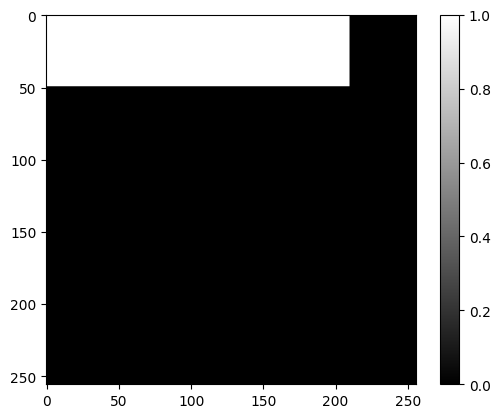

In [8]:
import matplotlib.pyplot as plt
from probjax.nn.pallas_kernels.attention_mask_bias import CausalMask, materialize_mask, LocalWindowMask, SameSegmentMask, KeyPaddingMask, QKVLengthMask, MarginalizationMask

mask = CausalMask()
mask = LocalWindowMask(32,32)
segment_id = jnp.arange(seq_len)
mask = SameSegmentMask(segment_id, segment_id[::-1])
mask = KeyPaddingMask(jnp.array([256]*256 + [64]*128 + [32]*128))
mask = QKVLengthMask(q_length=50, kv_length=210, block_sparse=False)
#mask = jax.random.bernoulli(jax.random.PRNGKey(0), p=0.5, shape=(seq_len,))
#mask = MarginalizationMask(mask)

plt.imshow(materialize_mask(mask, 256, 256), cmap='gray', vmin=0, vmax=1)
plt.colorbar()

In [22]:
mask.get_data()

(None, None)

In [7]:
mask.query_iterator_indices(seq_len, seq_len, 16, 16)
mask.kv_iterator_indices(seq_len, seq_len, 16, 16)

(None, None)

In [5]:
import math
out1 = dot_product_attention(q.astype(jnp.float32),k.astype(jnp.float32),v.astype(jnp.float32), mask=materialize_mask(mask,seq_len, seq_len))
out2 = jax.jit(flex_attention)(q.astype(jnp.float32),k.astype(jnp.float32),v.astype(jnp.float32), mask)
#out2 = flash_attention(q, k, v, mask_fn=lambda x,y: y > 50, softmax_scale=1/math.sqrt(64), interpret=True)

jnp.mean(jnp.abs(out1 - out2))

NameError: name 'materialize_mask' is not defined

In [27]:
def loss_fn1(q):
    out = dot_product_attention(q.astype(jnp.float32),k.astype(jnp.float32),v.astype(jnp.float32), mask=materialize_mask(CausalMask(),seq_len, seq_len))
    return jnp.sum((out-1)**2)
def loss_fn2(q):
    out = flex_attention(q.astype(jnp.float32),k.astype(jnp.float32),v.astype(jnp.float32), mask=CausalMask())
    return jnp.sum((out-1)**2)

grad1 = jax.grad(loss_fn1)(q)
grad2 = jax.grad(loss_fn2)(q)

In [28]:
jnp.allclose(grad1, grad2, atol=1e-2, rtol=1e-2)

Array(True, dtype=bool)

In [29]:
grad1

Array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0.628906, -0.0996094, 0.664062, ..., 0.167969, -0.519531,
          -0.378906],
         [1.72656, -0.316406, -0.0957031, ..., -1.46875, 0.259766,
          0.375],
         [-0.478516, -0.0908203, -0.0908203, ..., 0.18457, -0.267578,
          -0.392578],
         ...,
         [1.10938, 1.5, 2.53125, ..., 0.636719, -0.53125, -0.667969],
         [1.24219, 1.69531, 0.133789, ..., -0.15625, -0.176758,
          2.51562],
         [0.206055, -1.30469, 0.203125, ..., 0.0834961, -1.39062,
          -1.07031]],

        [[-1.14062, -0.902344, -1.39844, ..., -0.691406, 0.347656,
          -1.09375],
         [-0.482422, -0.535156, 0.738281, ..., 3.5, -2.4375, -1.26562],
         [0.314453, 0.191406, -0.022583, ..., -0.113281, 0.382812,
          0.363281],
        

In [30]:
grad1 - grad2

Array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [5.81145e-07, 1.03563e-06, -9.53674e-07, ..., -8.67993e-07,
          2.12342e-07, 1.70618e-06],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],


In [17]:
from functools import partial


_ = benchmark(attn_fn, q, k, v)

NameError: name 'attn_fn' is not defined

In [12]:
attn_fn = jax.jit(partial(flex_attention, mask=LocalWindowMask(32,32)))
_ = benchmark(attn_fn, q, k, v)

CPU Utilization: 32% +/- 2%
Memory Utilization: 4% +/- 0%
Average time taken: 216.02 ms


In [11]:
attn

NameError: name 'attn' is not defined

In [ ]:
attn_fn = jax.jit(dot_product_attention)
out3 = attn_fn(q, k, v)

In [ ]:
attn_fn = jax.jit(partial(flex_attention, sm_scale=1.))
out = attn_fn(q, k, v)

In [36]:
attn_fn = jax.jit(partial(flex_attention))
_ = benchmark(attn_fn, q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32), CausalMask())

TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function mha at /Users/manug/src/probjax/probjax/nn/pallas_kernels/attention.py:750 for custom_vjp fun. This value became a tracer due to JAX operations on these lines:

  operation a[35m:i32[2][39m = add b 1:i32[]
    from line /Users/manug/src/probjax/probjax/nn/pallas_kernels/utils.py:155:22 (fast_blockmask_causal)

  operation a[35m:i32[2][39m = mul b 128:i32[]
    from line /Users/manug/src/probjax/probjax/nn/pallas_kernels/utils.py:155:21 (fast_blockmask_causal)

  operation a[35m:i32[2][39m = sub b 1:i32[]
    from line /Users/manug/src/probjax/probjax/nn/pallas_kernels/utils.py:155:21 (fast_blockmask_causal)

  operation a[35m:i32[2][39m = min b 255:i32[]
    from line /Users/manug/src/probjax/probjax/nn/pallas_kernels/utils.py:155:9 (fast_blockmask_causal)

  operation a[35m:i32[2][39m = mul b 128:i32[]
    from line /Users/manug/src/probjax

In [21]:
mask = CausalMask()
#mask = LocalWindowMask(4,4)
#mask = QKVLengthMask(q_length=50, kv_length=30, block_sparse=False)
#mask = KeyPaddingMask(jnp.array([32]*64))
import math
def f(q):
    q = q.repeat(16, axis=-2)
    q = q.repeat(64, axis=-1)
    #return flash_attention(q,q,q, interpret=True, softmax_scale=1/math.sqrt(64)).sum(axis=(-2,-1))
    return flex_attention(q,q,q, mask=mask).sum(axis=(-2,-1))

def g(q):
    q = q.repeat(16, axis=-2)
    q = q.repeat(64, axis=-1)
    if mask is not None:
        mask_dense = materialize_mask(mask, q.shape[-3], q.shape[-3])
    else:
        mask_dense = None
    return nnx.dot_product_attention(q, q, q, mask=mask_dense).sum(axis=(-2,-1))


f_grad_jit = jax.jit(jax.grad(f))

In [22]:
seq_len = 64

J = jax.jacobian(f)(q[:,:seq_len,:1, :1].astype(jnp.float32)).reshape((seq_len,seq_len))

[[0]] [1]
[[0]] [1]


ValueError: `indices` must not be longer than `shape`: indices=(slice(None, None, None), Slice(start=JitTracer<~int32[]>, size=1, stride=1)), shape=(1,)

In [ ]:
J2 = jax.jacobian(g)(q[:,:seq_len,:1, :1].astype(jnp.float32)).reshape((seq_len,seq_len))

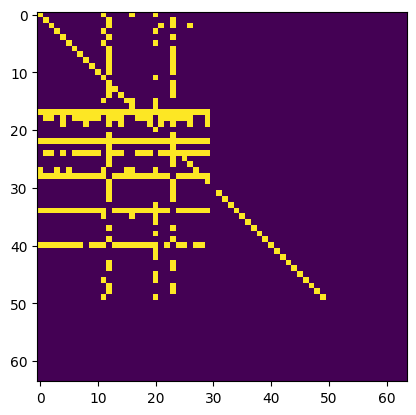

In [12]:
plt.imshow(J > 0)

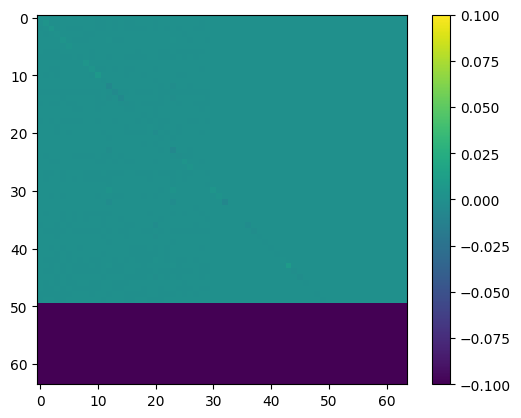

In [59]:
plt.imshow(J - J2, vmin=-0.1, vmax=0.1)
plt.colorbar()

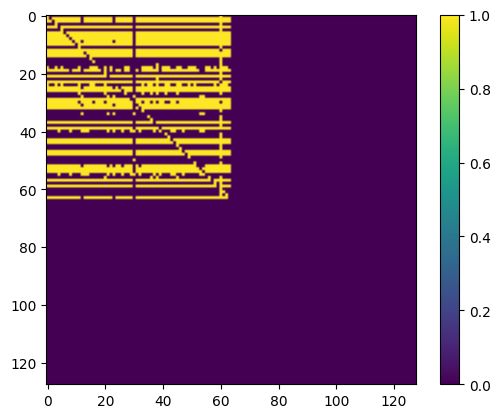

In [ ]:
plt.imshow(J > 0)
plt.colorbar()

In [ ]:
%%timeit
f_grad_jit(q).block_until_ready()

TypeError: Gradient only defined for scalar-output functions. Output had shape: (1, 2048).

In [ ]:
def f(q):
    return attn_fn(q,q.repeat(2, axis=1),q.repeat(2, axis=1)).sum()


f_grad_jit = jax.jit(jax.grad(f))

In [ ]:
%%timeit
f_grad_jit(q).block_until_ready()

6.58 ms ± 21.1 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
